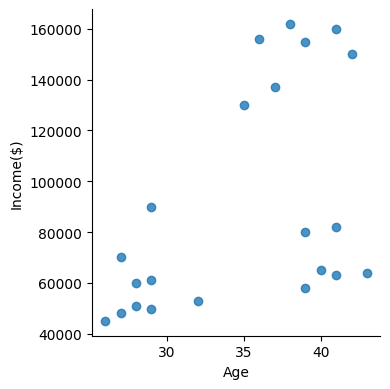

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
df = pd.read_csv("https://raw.githubusercontent.com/codebasics/py/master/ML/13_kmeans/income.csv")
sn.lmplot(x="Age", y="Income($)", data=df, fit_reg=False, height=4)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df[["Age", "Income($)"]])
scaled_df[0:5]

array([[-1.35605536, -0.48068427],
       [-1.00915747, -0.01015907],
       [-1.00915747, -0.69242061],
       [-1.18260641, -0.71594687],
       [ 1.24567876,  1.40141653]])

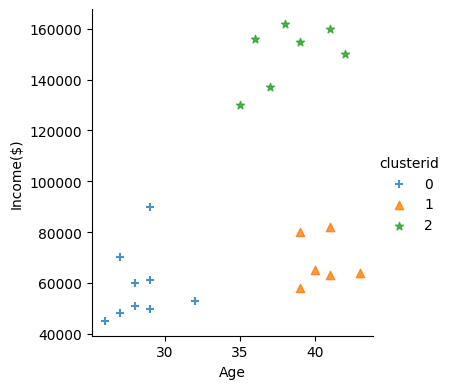

In [7]:
from sklearn.cluster import KMeans
clusters = KMeans(3)
clusters.fit(scaled_df)
df["clusterid"] = clusters.labels_
markers = ['+', '^', '*']
sn.lmplot(x="Age", y="Income($)", data = df, hue = "clusterid", fit_reg = False, markers  = markers, height = 4)

In [9]:
clusters = KMeans(3, random_state=0, n_init='auto') # Added random_state for reproducibility and n_init='auto' to avoid future warnings
clusters.fit(df[["Age", "Income($)"]]) # Fit on the numerical columns of df, or use scaled_df
df["new_clusterid"] = clusters.labels_
df.groupby("new_clusterid")[['Age', 'Income($)']].agg(["mean", 'std']).reset_index()

new_clusterid        Age                Income($)              
                      mean       std           mean           std
0             0  32.909091  6.456850   56136.363636   7071.389217
1             1  38.285714  2.563480  150000.000000  12069.244660
2             2  34.000000  7.023769   80500.000000   8225.975120

Text(0, 0.5, 'Sum of Squared Error')

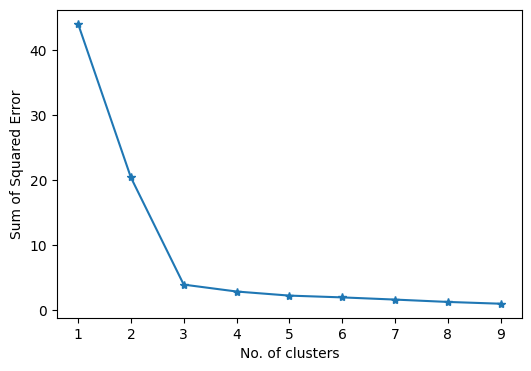

In [10]:
cluster_range = range(1,10)
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans(num_clusters)
  clusters.fit(scaled_df)
  cluster_errors.append(clusters.inertia_)
plt.figure(figsize = (6,4))
plt.plot(cluster_range, cluster_errors, marker = "*")
plt.xlabel("No. of clusters")
plt.ylabel("Sum of Squared Error")